# Оценка вакантности по домам (метод №2)

Альтернативная реализация самого главного шага исследования (см. Way 1). В научную статью не вошла, рецензирование не проходила, но все равно может быть интересна.

## Идея

Используем опросные данные, чтобы научиться по характеристикам квартир (площадь, этаж, свойства дома и другие) предсказывать количество живущих в них людей. Далее на базе такого предсказания можно посчитать ожидаемое число живущих в доме, сравнить его с числом зарегистрированных (то есть номинально живущих), и дать оценку числа вакантных квартир.


In [1]:
from collections import namedtuple
import datetime
import pathlib
import random

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import tqdm

pd.set_option("display.max_columns", None)

# Обучение модели для предсказания числа жителей в квартире

## Подготовка данных

Для тренировки модели используются данные комплексного обследования условий жизни населения (КОУЖ). КОУЖ — это репрезентативный опрос. Его проводит Росстат. Данные в удобном виде можно скачать в каталоге проекта «Если быть точным»: набор называется «[Микроданные выборочных обследований Росстата](https://tochno.st/datasets/surveys)». Берём 2022 год — самый новый из доступных.

In [2]:
kouz_base = pd.read_csv("../data/КОУЖ_2022_Датасет_по_домохозяйствам_основной.csv.gz", sep=";")
kouz_add = pd.read_csv("../data/КОУЖ_2022_Датасет_по_домохозяйствам_дополнительный.csv.gz", sep=";")
kouz = pd.concat([kouz_base, kouz_add])
kouz.head(2)

,H00_02,H00_04,H00_06,H00_07,H00_08,H00_09,H00_10,H00_11,H00_12,H00_13,H00_14,H01_15,H02_01,H02_02,H02_03,H02_04,H02_05_01,H02_05_02,H02_05_03,H02_05_04,H02_05_05,H02_06_01,H02_06_02,H02_06_03,H02_06_04,H02_07,H02_08_01,H02_08_02,H02_08_03,H02_08_04,H02_09_01,H02_09_02,H02_09_03,H02_09_04,H02_09_05,H02_09_06,H02_09_07,H02_09_08,H02_09_09,H02_10,H02_11,H02_111,H02_12_01,H02_12_02,H02_12_03,H02_12_04,H02_13_01_01,H02_13_01_02,H02_13_02_01,H02_13_02_02,H02_13_03_01,H02_13_03_02,H02_13_04_02,H02_14,H02_141,H02_15_01,H02_15_02,H02_15_03,H02_15_04,H02_15_05,H02_15_06,H02_16_01_01,H02_16_01_02,H02_16_02_01,H02_16_02_02,H02_16_03_01,H02_16_03_02,H02_16_04_01,H02_16_04_02,H02_16_05_01,H02_16_05_02,H02_17_01,H02_17_02,H02_18,H02_19_01,H02_19_02,H02_19_03,H02_191_01,H02_191_02,H02_20,H02_21,H02_22,H02_22a_01,H02_22a_02,H02_22a_03,H02_221_01,H02_221_02,H02_221_03,H02_23,H02_24_01,H02_24_02,H02_24_03,H02_24_04,H02_25,H02_26,H02_27,H02_28_01,H02_28_02,H02_28_03,H02_281,H02_29,H02_30,H02_301,H02_31_01,H02_31_02,H02_31_03,H02_31_04,H02_31_05,H02_31_06,H02_31_07,H02_311,H02_32_01,H02_32_02,H02_32_03,H02_32_04,H02_32_05,H02_32_06,H02_33,H02_34_01,H02_34_02,H02_34_03,H02_34_04,H02_35,H02_350,H02_351,H02_352,H02_353,H02_354_01,H02_354_02,H02_354_03,H02_354_04,H02_354_05,H02_354_06,H02_354_07,H02_355_01_01,H02_355_02_01,H02_355_03_01,H02_355_04_01,H02_355_05_01,H02_355_01_02,H02_355_02_02,H02_355_03_02,H02_355_04_02,H02_355_05_02,H02_356_01,H02_356_02,H02_356_03,H02_356_04,H02_356_05,H02_356_06,H02_356_07,H02_36_01_01,H02_36_01_02,H02_36_02_01,H02_36_02_02,H02_36_04_01,H02_36_04_02,H02_36_05_01,H02_36_05_02,H02_36_06_01,H02_36_06_02,H02_36_07_01,H02_36_07_02,H02_36_08_01,H02_36_08_02,H02_40_01,H02_40_02,H02_41_01,H02_41_02,H02_41_03,H02_41_04,H02_41_05,H02_41_06,H02_41_07,H02_41_08,H02_41_09,H02_42_01_01,H02_42_02_01,H02_42_03_01,H02_42_04_01,H02_42_01_02,H02_42_02_02,H02_42_03_02,H02_42_04_02,H02_42_01_03,H02_42_02_03,H02_42_03_03,H02_42_04_03,H02_43_01,H02_43_02,H02_43_03,H02_43_04,H02_43_05,H02_431,H02_44_01_01,H02_44_02_01,H02_44_03_01,H02_44_04_01,H02_44_05_01,H02_44_01_02,H02_44_02_02,H02_44_03_02,H02_44_04_02,H02_44_05_02,H02_44_01_03,H02_44_02_03,H02_44_03_03,H02_44_04_03,H02_44_05_03,H02_441_01_01,H02_441_02_01,H02_441_03_01,H02_441_04_01,H02_441_01_02,H02_441_02_02,H02_441_03_02,H02_441_04_02,H02_45,H02_46,H02_47,H02_48,H02_49,H02_501_01,H02_501_02,H02_501_03,H02_501_04,H02_501_05,H02_501_06,H02_501_07,H02_502_01,H02_502_02,H02_502_03,H02_502_04,H02_502_05,H02_502_06,H02_502_07,H02_503_01,H02_503_02,H02_503_03,H02_503_04,H02_503_05,H02_503_06,H02_503_07,H03_01,H03_02,H03_03_01,H03_03_02,H03_04,H03_05,H03_06_01,H03_06_02,H03_06_03,H03_06_04,H03_06_05,H03_06_06,H04_01_01,H04_01_02,H04_01_03,H04_01_04,H04_01_05,H04_01_06,H04_01_07,H04_01_08,H04_01_09,H04_01_10,H04_01_11,H04_01_12,H04_01_13,H04_01_14,H04_01_15,H04_01_16,H04_01_17,H04_02_01_01,H04_02_01_02,H04_02_02,H04_021,H04_03,H04_04_01,H04_04_02,H04_04_03,H04_04_04,H04_04_05,H04_04_06,H04_04_07,H04_04_08,H04_04_09,H04_05,H04_051,H04_06_01,H04_06_02,H04_07_01,H04_07_02,H04_07_03,H04_07_04,H04_07_05,H04_07_06,H04_07_07,H04_07_08,H04_07_09,H04_08,H05_01,H05_02_01_01,H05_02_02_01,H05_02_03_01,H05_02_04_01,H05_02_05_01,H05_02_06_01,H05_02_07_01,H05_02_08_01,H05_02_09_01,H05_02_10_01,H05_02_11_01,H05_02_12_01,H05_02_13_01,H05_02_14_01,H05_02_15_01,H05_02_16_01,H05_02_17_01,H05_02_18_01,H05_02_01_02,H05_02_02_02,H05_02_03_02,H05_02_04_02,H05_02_05_02,H05_02_06_02,H05_02_07_02,H05_02_08_02,H05_02_09_02,H05_02_10_02,H05_02_11_02,H05_02_12_02,H05_02_13_02,H05_02_14_02,H05_02_15_02,H05_02_16_02,H05_02_17_02,H05_02_18_02,H05_02_01_03,H05_02_02_03,H05_02_03_03,H05_02_04_03,H05_02_05_03,H05_02_06_03,H05_02_07_03,H05_02_08_03,H05_02_09_03,H05_02_10_03,H05_02_11_03,H05_02_12_03,H05_02_13_03,H05_02_14_03,H05_02_15_03,H05_02_16_03,H05_02_17_03,H05_02_18_03,H05_02_01_04,H05_02_02_04,H05_02_03_04,H05_02_04_04,H05_02_05_04,H05_02_06_04,H05_02_07_04,H05_02_08_04,H05_02_09_04,H05_02_10_04,H05_02_11_04,H05_02_1

In [3]:
kouz.shape

(99717, 420)

Основные шаги предобработки:
- выбираем признаки для обучения. Берём такие, которые можно на втором шаге найти в открытых данных;
- фильтруем наблюдения: только Москва (так как оцениваем вакантность по Москве), только домохозяйства, занимающие квартиру целиком (не дом, не часть квартиры, так как на втором шаге у нас квартиры);
- убираем дубли по номеру домохозяйства, так как в «основной» и «дополнительной» частях некоторые записи совпадают;
- переименовываем всё для удобства;
- приводим колонки к оптимальному типу данных (например, `bool` там, где подразумевается `True/False`), убираем пропуски;
- убираем наблюдения с более чем пятью жителями в одной квартире, так как их мало, и они ухудшают качество модели.

Описание оригинальных переменных из датасета КОУЖ можно посмотреть в кодбуке, который опубликован вместе с набором. Там же есть пример анкеты, в котором можно увидеть варианты ответов. Здесь постарался дать максимально интуитивные названия колонок.

In [4]:
features = {
    "H02_06_01": "flat_area_total",
    "H02_11": "house_construction_year",
    "H02_111": "house_wall_material",
    "H02_13_01_01": "house_has_elevator",
    "H02_13_02_01": "house_has_chute",
    "H02_14": "house_quality",
    "H02_141": "flat_floor",
    "H02_16_01_01": "house_has_playground",
    "H02_16_02_01": "house_has_sportsground",
    "H02_16_03_01": "house_has_parking",
    "H02_18": "house_cold_water_type",
    "H02_22": "house_serwage_type",
    "H02_27": "house_hot_water_type",
    "H02_29": "house_heating_type",
    "H02_32_01": "house_gas_counter_presence",
}
target = {"CHLIC": "flat_inhabitants_count"}

data = kouz.loc[
    (kouz["H02_01"] == 1) # entire flat households
    & (kouz["H00_02"] == 45) # Moscow only
].drop_duplicates(subset=["H00_06"])[list(features) + list(target)]
data.columns = list(features.values()) + list(target.values())
data.replace(-7.0, np.nan, inplace=True)
data.dropna(inplace=True)

data["flat_area_total"] = data["flat_area_total"].round()
data["house_has_elevator"] = (data["house_has_elevator"] - 2.0).astype(bool) # 2.0 is False
data["house_has_chute"] = (data["house_has_chute"] - 2.0).astype(bool) # 2.0 is False
data["house_has_sportsground"] = (data["house_has_sportsground"] - 2.0).astype(bool) # 2.0 is False
data["house_has_playground"] = (data["house_has_playground"] - 2.0).astype(bool) # 2.0 is False
data["house_has_parking"] = (data["house_has_parking"] - 2.0).astype(bool) # 2.0 is False

data["house_quality"] = data["house_quality"] == 1.0 # only 1.0 is official alarm status
data["house_gas_counter_presence"] = (data["house_gas_counter_presence"] - 3.0).astype(bool) # 3.0 is not applicable = no gas
data.rename(
    columns={
        "house_quality": "house_is_alarm",
        "house_gas_counter_presence": "house_has_gas"
    }, 
    inplace=True
)

data[data.select_dtypes(float).columns] = data.select_dtypes(float).astype(int)
data = data.loc[data["flat_inhabitants_count"] <= 5]

data.head(2)

,flat_area_total,house_construction_year,house_wall_material,house_has_elevator,house_has_chute,house_is_alarm,flat_floor,house_has_playground,house_has_sportsground,house_has_parking,house_cold_water_type,house_serwage_type,house_hot_water_type,house_heating_type,house_has_gas,flat_inhabitants_count
48309,60,4,2,True,True,False,4,True,True,True,1,1,1,1,True,1
48310,35,4,1,True,True,False,2,True,True,False,1,1,1,1,False,2


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4637 entries, 48309 to 39721
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   flat_area_total          4637 non-null   int64
 1   house_construction_year  4637 non-null   int64
 2   house_wall_material      4637 non-null   int64
 3   house_has_elevator       4637 non-null   bool 
 4   house_has_chute          4637 non-null   bool 
 5   house_is_alarm           4637 non-null   bool 
 6   flat_floor               4637 non-null   int64
 7   house_has_playground     4637 non-null   bool 
 8   house_has_sportsground   4637 non-null   bool 
 9   house_has_parking        4637 non-null   bool 
 10  house_cold_water_type    4637 non-null   int64
 11  house_serwage_type       4637 non-null   int64
 12  house_hot_water_type     4637 non-null   int64
 13  house_heating_type       4637 non-null   int64
 14  house_has_gas            4637 non-null   bool 
 15  flat

## Обучение и оценка качества модели

In [6]:
X = data.drop(columns=list(target.values()))
y = data[list(target.values())].iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=.25)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3477, 15), (1160, 15), (3477,), (1160,))

In [7]:
rfc = RandomForestClassifier(random_state=42, class_weight="balanced")
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
accuracy_score(y_test, y_pred), balanced_accuracy_score(y_test, y_pred)

(0.38017241379310346, np.float64(0.2698745345738762))

Сравниваем со случайным классификатором, учитывающим распределение классов.

In [8]:
class RandomClassifier(BaseEstimator):
    def __init__(self, random_state: int = 42):
        self._seed = random_state
        
    def fit(self, x, y):
        pass

    def predict(self, x):
        random.seed(self._seed)
        weights = list(y_train.value_counts().sort_index())
        return np.array(random.choices(range(1, 6), weights, k = len(x)))

In [9]:
rc = RandomClassifier()
p = pd.Series(rc.predict(X_test))
accuracy_score(y_test, p), balanced_accuracy_score(y_test, p, adjusted=True)

(0.28448275862068967, np.float64(-0.012426910230290064))

Визуализируем качество по классам.

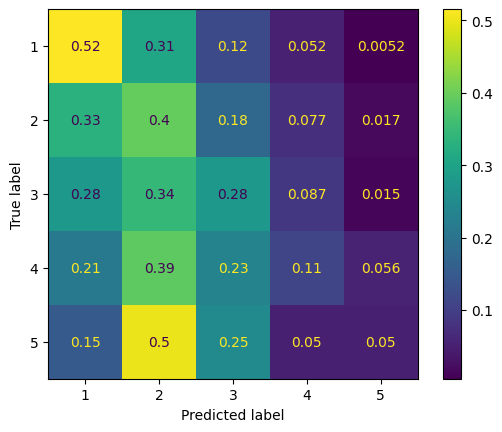

In [10]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, normalize="true"),
    display_labels=sorted(y.unique())               
).plot()

## Промежуточные выводы

1. Качество модели невысокое, но выше, чем у случайного классификатора. Значит, какая-то польза от неё есть.
2. Чем больше жителей в квартире, тем хуже справляется модель, то есть в целом она склоняется к тому, чтобы предсказывать 1–2 жителей.

## Дискуссионные моменты

### Набор признаков

Поиск с помощью Recursive Feature Elimination (RFE) показывает, что можно чуть-чуть улучшить качество, если отбросить некоторые признаки.

### Гиперпараметры

Grid Search не даёт прироста в качестве.

### Метрика
Теоретически вроде лучше брать взвешенную точность, но фактически как будто разницы нет.

### Формулировка задачи

Классификация позволят избежать оценок вида «2.34567 жителей в квартире», но есть проблема дисбаланса классов.

### Алгоритм

XGBoost, CatBoost, LightGBM не дают большого прироста.

### Данные для обучения

КОУЖ содержит больше всего подходящих наблюдений и переменных. 

Альтернативы:
 - [Всероссийское обследование домохозяйств по потребительским финансам Банка России](https://www.cbr.ru/ec_research/vserossiyskoe-obsledovanie-domokhozyaystv-po-potrebitel-skim-finansam/);
 - [Российский мониторинг экономического положения и здоровья населения НИУ ВШЭ НИУ ВШЭ](https://www.hse.ru/rlms/).

В обоих меньше как признаков, так и наблюдений, поэтому качество модели получается ещё хуже.

Эксперименты были, но в тетрадку не включены. Что-то можно найти в тетрадке EDA, но там всё свалено в кучу и не подготовлено для использования.

# Оценка вакантности с помощью подготовленной модели

## Загрузка и подготовка данных

- `flats_mapping` — соотнесение `id` домов и кадастровых номеров квартир. Получен с помощью скрипта `extract_gisgkh.py`. См. также тетрадку №3.
- `flats_properties` — свойства квартир: кадастровый номер, площадь, этаж. Похож на `flats_mapping`, который используется в Way 1, и тоже получен из данных кадастровой оценки, но с помощью другого скрипта — `parse_cad_assessment_data.py`. Наверное, можно было бы их объединить, но пусть будет как есть.
- `houses` — реестр домов из открытых данных ФРТ (см. также пояснения в тетрадке №1).
- `repair_data` — данные по капремонту из ФРТ (см. также пояснения в тетрадке №2).
- `geo` — вспомогательные геоданные из тетрадки №1.

In [11]:
flats_mapping = pd.read_parquet("../data/flats.parquet")
flats_properties = pd.read_parquet("../data/flats_props.parquet")
geo = pd.read_parquet("../data/houses_coords.parquet")
houses = pd.read_csv("../data/export-reestrmkd-77-20250301.zip", sep=";", decimal=",")
repair_data = pd.read_csv("../data/export-kr1_1-77-20250301.zip", sep=";", decimal=",")

In [12]:
houses.head(2)

,id,region_id,area_id,city_id,street_id,shortname_region,formalname_region,shortname_area,formalname_area,shortname_city,formalname_city,shortname_street,formalname_street,house_number,building,block,letter,address,houseguid,management_organization_id,built_year,exploitation_start_year,project_type,house_type,is_alarm,method_of_forming_overhaul_fund,floor_count_max,floor_count_min,entrance_count,elevators_count,energy_efficiency,quarters_count,living_quarters_count,unliving_quarters_count,area_total,area_residential,area_non_residential,area_common_property,area_land,parking_square,playground,sportsground,other_beautification,foundation_type,floor_type,wall_material,basement_area,chute_type,chute_count,electrical_type,electrical_entries_count,heating_type,hot_water_type,cold_water_type,sewerage_type,sewerage_cesspools_volume,gas_type,ventilation_type,firefighting_type,drainage_type
0,8649748,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,NaN,г,Москва,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,NaN,"г. Москва, д. 9, к. 1",521474b9-1d5a-702f-3b75-33ff10263733,7628409.0,1973.0,1973.0,П-49-04/70Д,Многоквартирный дом,Нет,На счете регионального оператора,9.0,9.0,4.0,4.0,Не присвоен,144,144.0,0.0,7219.0,4940.0,0.0,2279.0,0.0,0.0,500,500,NaN,Бетонные столбы,Железобетонные,Панельные,1159.0,На лестничной клетке,4.0,Центральное,1.0,Центральное,Закрытая с приготовлением горячей воды на ЦТП,Центральное,Центральное,0.0,Центральное,Вытяжная вентиляция,Отсутствует,Внутренние водостоки
1,9370109,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,NaN,г,Москва,NaN,NaN,NaN,NaN,NaN,NaN,14,NaN,1,NaN,"г. Москва, д. 14, к. 1",64f12da8-00f6-ab7c-a849-2e1c3cccd26b,NaN,NaN,NaN,NaN,Не заполнено,Нет,Не заполнено,NaN,NaN,NaN,NaN,Не заполнено,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,498,498,NaN,Не заполнено,Не заполнено,Не заполнено,NaN,Не заполнено,NaN,Не заполнено,NaN,Не заполнено,Не заполнено,Не заполнено,Не заполнено,NaN,Не заполнено,Не заполнено,Не заполнено,Не заполнено


In [13]:
repair_data.head(2)

,subject_rf,mun_obr_oktmo,mun_obr,mkd_code,houseguid,address,commission_year,architectural_monument_category,total_sq,total_rooms_amount,living_rooms_amount,total_rooms_sq,living_rooms_sq,total_ppl,number_floors_max,money_collecting_way,money_ppl_collected,money_ppl_collected_debts,overhaul_funds_spent_all,overhaul_funds_spent_subsidy,overhaul_fund_spent_other,overhaul_funds_balance,update_date_of_information,money_ppl_collected_date,owners_payment,energy_efficiency,alarm_document_date,exclude_date_from_program,inclusion_date_to_program,comment,last_update,house_id
0,город Москва,45397000,Академический район,108367,fa844609-84ef-4f05-8414-74b25c56fce1,60-летия Октября просп. 10/1,1964,NaN,3448.0,71,68,3352.46,2429.13,136,9,Счет регионального оператора,7059.18318,22.57946,1597.26244,NaN,NaN,5461.92074,2025-01-15,01.01.2015,29.66,NaN,NaN,NaN,29.12.2014,NaN,23.01.2025,8004177.0
1,город Москва,45397000,Академический район,104062,6793bac3-20b7-4e42-b53a-73dc9be6c309,60-летия Октября просп. 12,1963,NaN,3457.0,75,68,3251.41,2539.72,129,9,Счет регионального оператора,6772.90899,90.33989,13380.14323,NaN,NaN,-6607.23424,2025-01-15,01.01.2015,29.66,NaN,NaN,NaN,29.12.2014,NaN,23.01.2025,8004180.0


In [14]:
geo.head(2)

,house_id,lat,lon
0,8929489,55.727066,37.560168
1,8065593,55.727066,37.560168


In [15]:
flats_mapping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5318579 entries, 0 to 5318578
Data columns (total 2 columns):
 #   Column                                            Dtype 
---  ------                                            ----- 
 0   Глобальный уникальный идентификатор дома по ФИАС  object
 1   Кадастровый номер                                 object
dtypes: object(2)
memory usage: 81.2+ MB


In [16]:
flats_properties.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4952236 entries, 0 to 92449
Data columns (total 3 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flat_cad_number  object 
 1   flat_area        int64  
 2   flat_floor       float64
dtypes: float64(1), int64(1), object(1)
memory usage: 151.1+ MB


In [17]:
flats_mapping.columns = ["houseguid", "flat_cad_number"]
flats = flats_mapping.merge(flats_properties)
flats.dropna(inplace=True)
flats["flat_area"] = flats["flat_area"].round()
flats.rename(columns={"flat_area": "flat_area_total"}, inplace=True)
flats[flats.select_dtypes(float).columns] = flats.select_dtypes(float).astype(int)
flats.drop(columns=["flat_cad_number"], inplace=True)
flats.head()

,houseguid,flat_area_total,flat_floor
0,021f35f5-fe8e-4291-b7f1-48eecca62b6e,87,2
1,021f35f5-fe8e-4291-b7f1-48eecca62b6e,123,2
2,021f35f5-fe8e-4291-b7f1-48eecca62b6e,91,2
3,021f35f5-fe8e-4291-b7f1-48eecca62b6e,228,2
4,021f35f5-fe8e-4291-b7f1-48eecca62b6e,154,2


In [18]:
flats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4571219 entries, 0 to 4573345
Data columns (total 3 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   houseguid        object
 1   flat_area_total  int64 
 2   flat_floor       int64 
dtypes: int64(2), object(1)
memory usage: 139.5+ MB


Выбираем признаки, соответствующие тем, на которых обучалась модель, и приводим их к тому же типу и «размерности».

### Пояснения к признакам

1. `houseguid` — сквозной идентификатор дома по открытым данным ФРТ и по ГИС ЖКХ. Нужен, чтобы связать реестр домов с данными по капремонту и с квартирами.
2. `house_construction_year` — год постройки дома. Переводим в категории, совпадающие с КОУЖ.
3. `house_is_alarm` — является ли дом аварийным.
4. `house_has_elevator`, `house_has_chute`, `house_has_parking` — есть ли в доме лифт, мусоропровод, есть ли рядом парковка. Если в реестре домов соответствующее число больше нуля, то есть. Количество не важно, так как в КОУЖ это бинарная переменная.
5. `house_has_playground`, `house_has_sportsground` — есть ли рядом с домом детская или спортивная площадка. Переводим коды в бинарную переменную. Коды реестра домов нигде не задокументированы, но можно вычислить, если взять дома с разными кодами и посмотреть их на сайте ФРТ.
6. `house_wall_material` — материал стен. Переводим классы реестра домов в классы КОУЖ. Описания классов КОУЖ есть в кодбуке КОУЖ. Местами не совсем понятно, что чему соответствует — ставим исходя из здравого смысла.
7. `house_cold_water_type`, `house_hot_water_type`, `house_heating_type`, `house_serwage_type` — тип холодного, горячего водоснабжения, отопления, канализации. Перекодируем классы реестра домов в классы КОУЖ. Описания классов, опять же, есть в кодбуке и в образцах форм КОУЖ, а сопоставление в сложных случаях опирается на здравый смысл.
8. `house_has_gas` — есть ли в доме газоснабжение. Бинарная переменная на базе классификации в реестре домов.

In [19]:
houses_properties = houses[["houseguid"]].copy()
houses_properties["house_construction_year"] = pd.cut(
    x=houses["built_year"],
    bins=[1147, 1920, 1945, 1956, 1970, 1995, 2012, datetime.date.today().year + 1],
    labels=[1, 2, 3, 4, 5, 6, 7],
).astype(float)
houses_properties["house_is_alarm"] = houses["is_alarm"] == "Да"
houses_properties["house_has_elevator"] = houses["elevators_count"] > 0
houses_properties["house_has_chute"] = houses["chute_count"] > 0
houses_properties["house_has_parking"] = houses["parking_square"] > 0
houses_properties["house_has_playground"] = houses["playground"].map({
    499: True,
    500: False,
    498: np.nan,
})
houses_properties["house_has_sportsground"] = houses["sportsground"].map({
    499: True,
    500: False,
    498: np.nan,
})
houses_properties["house_wall_material"] = houses["wall_material"].map({
    "Кирпич": 1,
    "Железобетон": 2,
    "Блочные": 2,
    "Панельные": 2,
    "Монолитные": 3,
    "Смешанные": 5,
    "Деревянные": 4,
    "Иные": 6,
    "Железобетонная панель": 2,
    "Шлакобетон (блоки)": 2,
    "Керамзитобетон": 2,  
})
houses_properties["house_cold_water_type"] = houses["cold_water_type"].map({
    "Центральное": 1,
    "Отсутствует": 4,
    "Автономное": 2,
})
houses_properties["house_hot_water_type"] = houses["hot_water_type"].map({
    "Закрытая с приготовлением горячей воды на ЦТП": 1,                                
    "Открытая с отбором сетевой воды на горячее водоснабжение из тепловой сети": 2,
    "Отсутствует": 3,                                                                 
    "Квартирное (квартирный котел)": 2,                                                
    "Закрытая с приготовлением горячей воды на ИТП": 2,                                  
    "Автономная котельная (крышная, встроенно-пристроенная)": 2,                        
    "Печное": 2,
})
houses_properties["house_heating_type"] = houses["heating_type"].map({
    "Центральное": 1,
    "Квартирное отопление (квартирный котел)": 2,
    "Автономная котельная (крышная, встроенно-пристроенная)": 2,
    "Индивидуальный тепловой пункт (ИТП)": 2,
    "Отсутствует": 4,
    "Печное": 3,
})
houses_properties["house_serwage_type"] = houses["sewerage_type"].map({
    "Центральное": 1,
    "Отсутствует": 4,
    "Автономное": 2,
})
houses_properties["house_has_gas"] = houses["gas_type"].map({
    "Центральное": True,
    "Отсутствует": False,
    "Автономное": True,
})

houses_properties.dropna(inplace=True)
houses_properties[houses_properties.select_dtypes(float).columns] = houses_properties.select_dtypes(float).astype(int)
houses_properties["house_has_gas"] = houses_properties["house_has_gas"].astype(bool)
houses_properties["house_has_playground"] = houses_properties["house_has_playground"].astype(bool)
houses_properties["house_has_sportsground"] = houses_properties["house_has_sportsground"].astype(bool)

houses_properties.head()

,houseguid,house_construction_year,house_is_alarm,house_has_elevator,house_has_chute,house_has_parking,house_has_playground,house_has_sportsground,house_wall_material,house_cold_water_type,house_hot_water_type,house_heating_type,house_serwage_type,house_has_gas
0,521474b9-1d5a-702f-3b75-33ff10263733,5,False,True,True,False,False,False,2,1,1,1,1,True
3,4b9cbbad-b371-6ce1-bebe-09e785d0b894,5,False,True,True,False,True,True,2,1,1,1,1,False
11,723e2dcf-d203-4dc1-89de-9b41f453916a,1,False,False,True,False,False,False,1,1,2,1,1,True
12,8425ff55-ec42-466a-a993-de4e5faaba3b,4,False,True,True,False,False,False,1,1,1,1,1,True
13,a8ad9e0b-e0c1-46a7-981c-4d5a598c76ce,3,False,True,True,False,False,False,1,1,1,1,1,True


In [20]:
houses_properties.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31959 entries, 0 to 34702
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   houseguid                31959 non-null  object
 1   house_construction_year  31959 non-null  int64 
 2   house_is_alarm           31959 non-null  bool  
 3   house_has_elevator       31959 non-null  bool  
 4   house_has_chute          31959 non-null  bool  
 5   house_has_parking        31959 non-null  bool  
 6   house_has_playground     31959 non-null  bool  
 7   house_has_sportsground   31959 non-null  bool  
 8   house_wall_material      31959 non-null  int64 
 9   house_cold_water_type    31959 non-null  int64 
 10  house_hot_water_type     31959 non-null  int64 
 11  house_heating_type       31959 non-null  int64 
 12  house_serwage_type       31959 non-null  int64 
 13  house_has_gas            31959 non-null  bool  
dtypes: bool(7), int64(6), object(1)
memory usag

Собираем поквартирную таблицу. Одна строка — одна квартира. Свойства квартиры — это свойства дома и собственные свойства квартиры. Свойства дома взяты из предыдущей таблицы, а собственных свойств квартиры два: площадь (`flat_area_total`) и этаж (`flat_floor`). Также добавлены код региона (`region_code`) и общее число жителей в доме (`house_total_ppl`). В итоге получаем набор данных с такими же признаками того же типа, что использовался для обучения модели.

In [21]:
flats_with_house_info = flats.merge(houses_properties)
flats_with_house_info["region_code"] = 45  # Moscow
flats_with_house_info = flats_with_house_info.merge(repair_data[["houseguid", "total_ppl"]])
flats_with_house_info = flats_with_house_info.loc[
    (flats_with_house_info["flat_area_total"] > 10) & (flats_with_house_info["flat_area_total"] < 250)
    & (flats_with_house_info["flat_floor"] >= 1) & (flats_with_house_info["flat_floor"] < 75)
    & (flats_with_house_info["total_ppl"] > 10) & (flats_with_house_info["total_ppl"] < 3000)
]
flats_with_house_info.rename(columns={"total_ppl": "house_total_ppl"}, inplace=True)
flats_with_house_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170376 entries, 0 to 3410589
Data columns (total 18 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   houseguid                object
 1   flat_area_total          int64 
 2   flat_floor               int64 
 3   house_construction_year  int64 
 4   house_is_alarm           bool  
 5   house_has_elevator       bool  
 6   house_has_chute          bool  
 7   house_has_parking        bool  
 8   house_has_playground     bool  
 9   house_has_sportsground   bool  
 10  house_wall_material      int64 
 11  house_cold_water_type    int64 
 12  house_hot_water_type     int64 
 13  house_heating_type       int64 
 14  house_serwage_type       int64 
 15  house_has_gas            bool  
 16  region_code              int64 
 17  house_total_ppl          int64 
dtypes: bool(7), int64(10), object(1)
memory usage: 311.4+ MB


In [22]:
flats_with_house_info["houseguid"].nunique()

23090

## Оценка вакантности

1. Берём дом.
2. Перебираем квартиры в произвольном порядке (считаем, что порядок в данных подходит, так как не зависит от свойств квартиры) и просим модель предсказать распределение вероятностей того или иного числа жителей.
3. Из этого распределения случайным образом извлекаем число жителей в данной квартире.
4. Суммируем полученные числа до тех пор, пока не получим число жителей в доме. Если остановились, и в доме ещё остались квартиры, то считаем их вакантными, иначе вакантных квартир 0. Если не остановились, и квартиры в доме закончились, то вакантных квартир 0.
5. Повторяем так 1000 раз, получая разные оценки числа вакантных квартир. Агрегируем их: считаем среднее, медиану, стандартное отклонение.

В коде это выглядит по-другому для оптимизации, но суть та же.

In [23]:
HouseVacantInfo = namedtuple("HouseVacantInfo", ["houseguid", "total_flats", "vacant_mean", "vacant_median", "vacant_std"])
result = []
for houseguid, house_data in tqdm.tqdm(flats_with_house_info.groupby("houseguid")):
    total_ppl = house_data["house_total_ppl"].iat[0]
    total_flats = len(house_data)
    
    X_test = house_data[rfc.feature_names_in_]
    probs = rfc.predict_proba(X_test)
    trials = np.apply_along_axis(lambda row: np.random.choice(np.arange(1, 6, dtype=np.uint8), 1000, p=row), axis=1, arr=probs)
    cumulative = trials.cumsum(axis=0)
    cumulative = np.concatenate(
        [cumulative,
        np.array([[total_ppl] * 1000])],  # support for edge case when cumulative sum is less than total_ppl
        axis=0,
    )
    masked = cumulative >= total_ppl
    est_flats_cnt = masked.argmax(axis=0)
    vacant_flats_cnt = total_flats - est_flats_cnt
    
    vacant_flats_mean = vacant_flats_cnt.mean()
    vacant_flats_median = np.median(vacant_flats_cnt)
    vacant_flats_std = vacant_flats_cnt.std()
    result.append(HouseVacantInfo(
        houseguid=houseguid,
        total_flats=total_flats,
        vacant_mean=vacant_flats_mean,
        vacant_median=vacant_flats_median,
        vacant_std=vacant_flats_std,        
    ))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 23090/23090 [17:10<00:00, 22.41it/s]


Соберём результат в датафрейм, добавим координаты и муниципальные образования для более удобного анализа.

In [26]:
vacant = (
    pd.DataFrame(result)
    .merge(houses[["houseguid", "id", "exploitation_start_year"]], how="left", on="houseguid")
    .rename(columns={"id": "house_id"})
    .merge(geo, how="left", on="house_id")
    .merge(repair_data[["houseguid", "mun_obr", "total_ppl"]], how="left", on="houseguid")
    .drop_duplicates(subset="houseguid")
    .dropna(subset=["lat", "lon"])
    .rename(columns={"total_flats": "total_flats_count", "vacant_median": "vacant_flats_count"})
)
vacant["vacant_flats_share"] = vacant["vacant_flats_count"].round() / vacant["total_flats_count"]
vacant = vacant[[
    "houseguid", "mun_obr", "lat", "lon", "exploitation_start_year",
    "total_ppl", "total_flats_count", "vacant_flats_count", "vacant_flats_share"
]]
vacant.head()

,houseguid,mun_obr,lat,lon,exploitation_start_year,total_ppl,total_flats_count,vacant_flats_count,vacant_flats_share
0,00095edb-6cf9-41b4-985c-bf942cf9717e,Алексеевский район,55.814135,37.653374,1959.0,166,70,0.0,0.000000
1,0009f2bb-b015-43c7-a166-51a33911c520,Ярославский район,55.851970,37.680949,1972.0,190,95,24.0,0.252632
2,000bfbb7-0d1b-4372-978c-30d03fbb4542,район Нагатино-Садовники,55.668580,37.657138,1964.0,137,71,0.0,0.000000
3,000e49e8-1c7e-42c6-90cb-9349c512a349,район Орехово-Борисово Южное,55.608386,37.726492,1977.0,169,70,0.0,0.000000
4,00132426-0b90-4f06-b4ef-702459c54ef4,Бабушкинский район,55.863683,37.679923,1970.0,166,84,0.0,0.000000


In [27]:
vacant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20926 entries, 0 to 23222
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   houseguid                20926 non-null  object 
 1   mun_obr                  20926 non-null  object 
 2   lat                      20926 non-null  float64
 3   lon                      20926 non-null  float64
 4   exploitation_start_year  20924 non-null  float64
 5   total_ppl                20926 non-null  int64  
 6   total_flats_count        20926 non-null  int64  
 7   vacant_flats_count       20926 non-null  float64
 8   vacant_flats_share       20926 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 1.6+ MB


Будем считать в данном случае нулевой результат неправдоподобным, потому что вряд ли существуют полностью заселённые дома. Уберём лишнее и посчитаем статистику.

In [33]:
vacant_correct = vacant.loc[vacant["vacant_flats_share"] > 0]

In [37]:
vacant_correct["vacant_flats_share"].describe()

count    7951.000000
mean        0.183733
std         0.151376
min         0.002165
25%         0.071909
50%         0.148810
75%         0.250000
max         0.978300
Name: vacant_flats_share, dtype: float64

<Axes: >

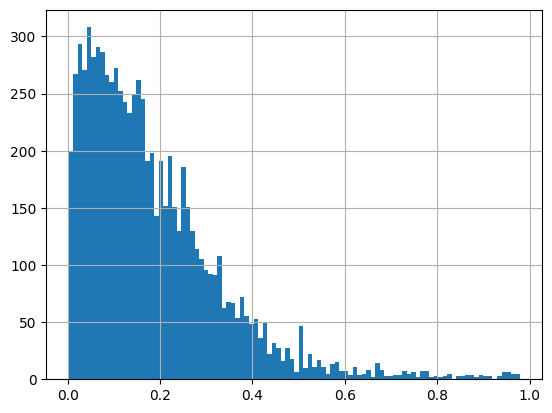

In [35]:
vacant_correct["vacant_flats_share"].hist(bins=100)

In [39]:
pathlib.Path("../result").mkdir(parents=True, exist_ok=True)
vacant_correct.to_csv("../result/vacant_w2.csv", index=False)

# Итоги

## Плюсы

1. Оно тоже работает, хотя и помедленнее.
2. В теории это должно давать более точный результат, и 12–15% пустующих квартир из валидных выглядят более правдоподобно, чем 30–35%, полученные первым способом.

## Минусы

1. Точность классификатора невысока, и очевидных путей повышения качества нет.
2. Валидный результат есть менее чем для трети домов из исходного набора. Для агрегации по районам этого достаточно, для детальной аналитики по домам — вряд ли. Скорее всего, проблема в том, что классификатор занижает число жителей.